In [124]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
from spacy import displacy
from spacy import tokenizer
import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer
from nltk.corpus import stopwords
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import gensim
import gensim.corpora as corpora
from gensim.models.coherencemodel import CoherenceModel
from gensim.models import LsiModel, TfidfModel
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

In [125]:
plt.rcParams['figure.figsize'] = (12,8)
default_plot_colour = "Green"

In [126]:
data = pd.read_csv("fake_news_data.csv")

Text(0.5, 1.0, 'Count of Article Classification')

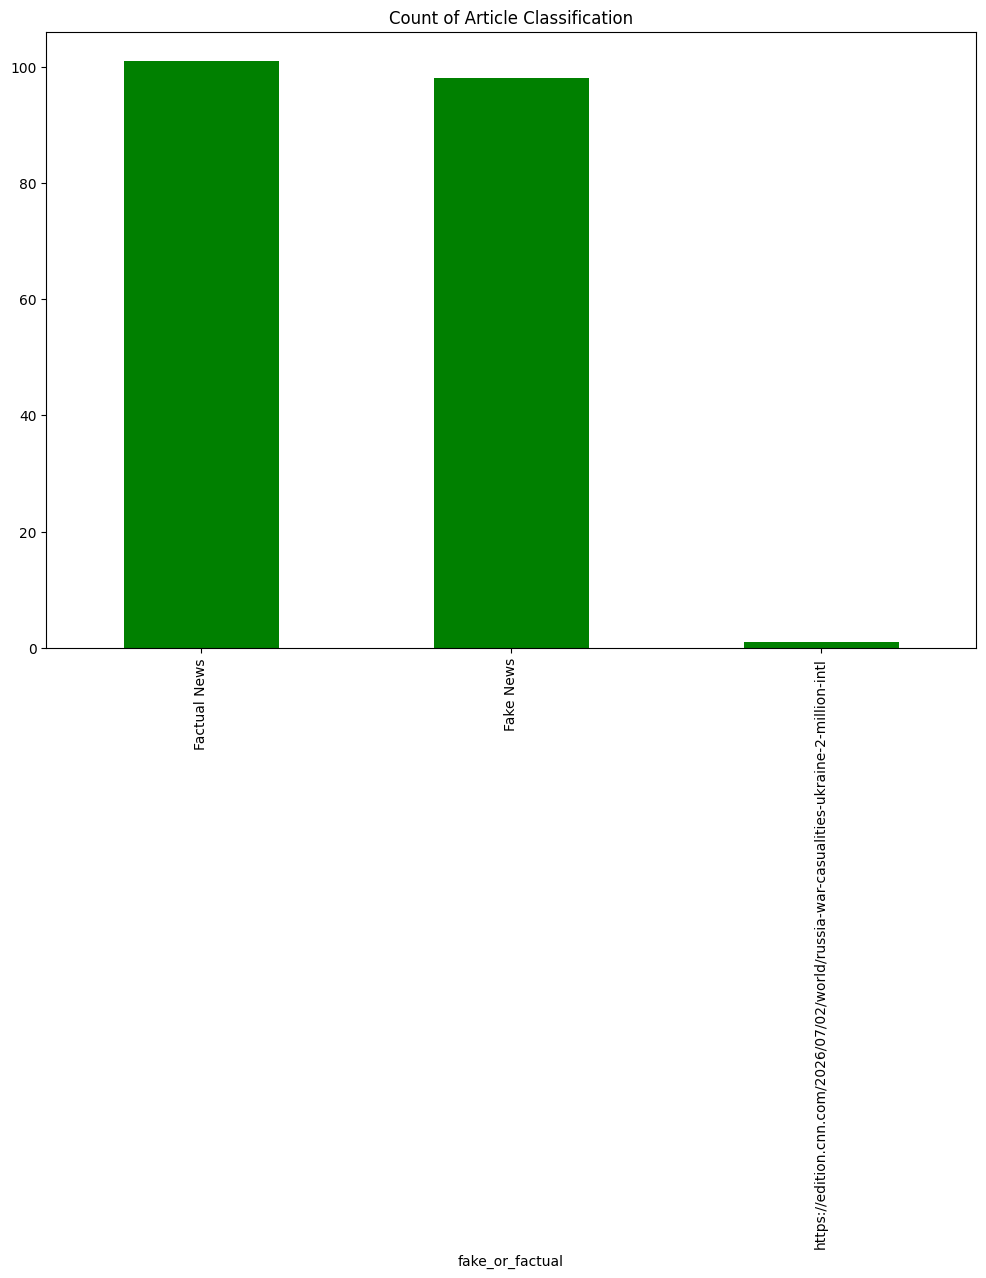

In [127]:
data['fake_or_factual'].value_counts().plot(kind='bar', color=default_plot_colour)
plt.title("Count of Article Classification")

In [128]:
nlp = spacy.load('en_core_web_sm')

In [129]:
fake_news = data[data['fake_or_factual'] == 'Fake News']
fact_news = data[data['fake_or_factual'] == 'Factual News']

In [130]:
fake_spacydocs = list(nlp.pipe(fake_news['text']))
fact_spacydocs = list(nlp.pipe(fact_news['text']))

In [131]:
def extract_token_tags(doc:spacy.tokens.doc.Doc):
    return[(i.text, i.ent_type_,i.pos_) for i in doc]

In [132]:
fake_tagsdf = []
columns = ["token", "ner_tag", "pos_tag"]

In [133]:
for ix, doc in enumerate(fake_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fake_tagsdf.append(tags)

In [134]:
fake_tagsdf = pd.concat(fake_tagsdf)

In [135]:
fact_tagsdf = []

for ix, doc in enumerate(fact_spacydocs):
    tags = extract_token_tags(doc)
    tags = pd.DataFrame(tags)
    tags.columns = columns
    fact_tagsdf.append(tags)

In [136]:
fact_tagsdf = pd.concat(fact_tagsdf)

In [137]:
fake_tagsdf.head()

,token,ner_tag,pos_tag
0,There,,PRON
1,are,,VERB
2,two,CARDINAL,NUM
3,small,,ADJ
4,problems,,NOUN


In [138]:
pos_counts_fake = fake_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name="counts").sort_values(by="counts",ascending=False)
pos_counts_fake.head(10)

,token,pos_tag,counts
29,",",PUNCT,1908
7451,the,DET,1834
41,.,PUNCT,1530
5766,of,ADP,922
2665,and,CCONJ,875
2449,a,DET,805
0,,SPACE,795
7528,to,PART,767
4921,in,ADP,668
5099,is,AUX,419


In [139]:
pos_counts_fact = fact_tagsdf.groupby(['token', 'pos_tag']).size().reset_index(name="counts").sort_values(by="counts",ascending=False)
pos_counts_fact.head(10)

,token,pos_tag,counts
6217,the,DET,1931
19,",",PUNCT,1727
26,.,PUNCT,1405
4776,of,ADP,893
1932,a,DET,793
2128,and,CCONJ,771
4058,in,ADP,683
6278,to,PART,672
4803,on,ADP,483
5633,said,VERB,457


In [140]:
pos_counts_fake.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2586
VERB     1817
PROPN    1672
ADJ       882
ADV       413
NUM       221
PRON       96
ADP        89
AUX        62
SCONJ      51
Name: token, dtype: int64

In [141]:
pos_counts_fact.groupby('pos_tag')['token'].count().sort_values(ascending=False).head(10)

pos_tag
NOUN     2194
VERB     1556
PROPN    1398
ADJ       756
ADV       266
NUM       212
PRON       81
ADP        70
AUX        43
SCONJ      42
Name: token, dtype: int64

In [142]:
pos_counts_fake[pos_counts_fake.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
5981,people,NOUN,77
7349,t,NOUN,65
6216,president,NOUN,58
7960,women,NOUN,55
7516,time,NOUN,52
3138,campaign,NOUN,44
8011,year,NOUN,44
4581,government,NOUN,41
5213,law,NOUN,40
8013,years,NOUN,40


In [143]:
pos_counts_fact[pos_counts_fact.pos_tag == "NOUN"][:15]

,token,pos_tag,counts
3788,government,NOUN,71
6693,year,NOUN,65
5970,state,NOUN,57
2398,bill,NOUN,55
2009,administration,NOUN,51
5128,president,NOUN,49
3322,election,NOUN,48
4980,people,NOUN,45
4846,order,NOUN,45
2536,campaign,NOUN,42


In [144]:
top_entities_fake = fake_tagsdf[fake_tagsdf['ner_tag']!= ""].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by="counts",ascending=False)

In [145]:
top_entities_fact = fact_tagsdf[fact_tagsdf['ner_tag']!= ""].groupby(['token','ner_tag']).size().reset_index(name='counts').sort_values(by="counts",ascending=False)

In [146]:
ner_palette = {
    'ORG': sns.color_palette("Set2").as_hex()[0],
    'GPE': sns.color_palette("Set2").as_hex()[1],
    'NORP': sns.color_palette("Set2").as_hex()[2],
    'PERSON': sns.color_palette("Set2").as_hex()[3],
    'DATE': sns.color_palette("Set2").as_hex()[4],
    'CARDINAL': sns.color_palette("Set2").as_hex()[5],
    'PERCENT': sns.color_palette("Set2").as_hex()[6]
}

[Text(0.5, 1.0, 'Most common Entities in Fake News')]

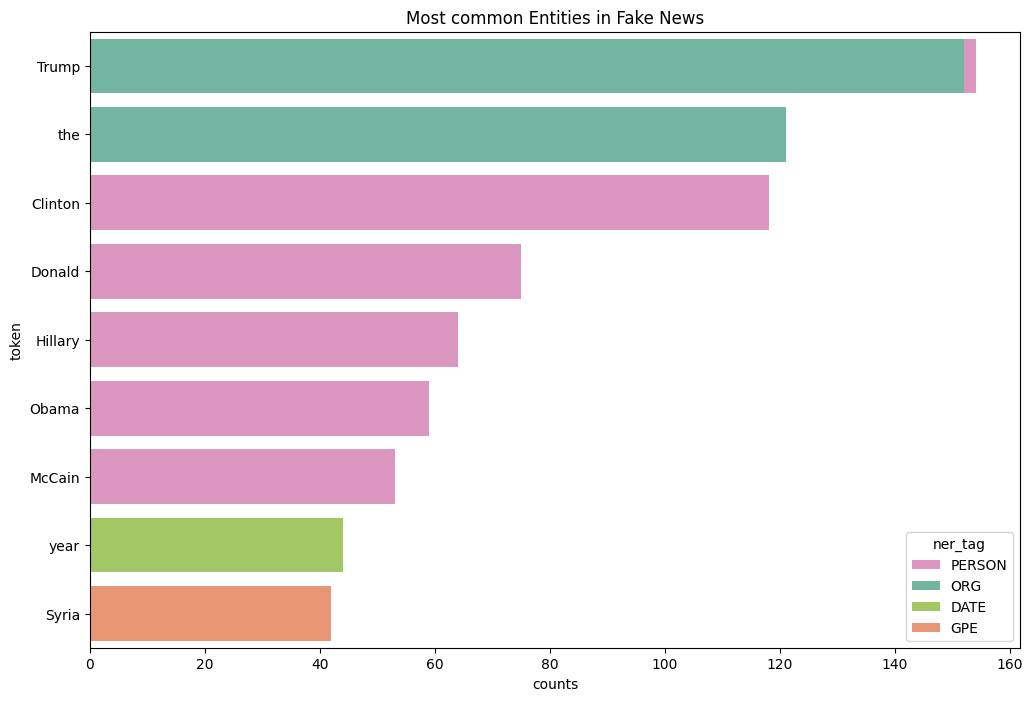

In [147]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fake[:10],
    orient = 'h',
    dodge = False
).set(title="Most common Entities in Fake News")

[Text(0.5, 1.0, 'Most common Entities in Fact News')]

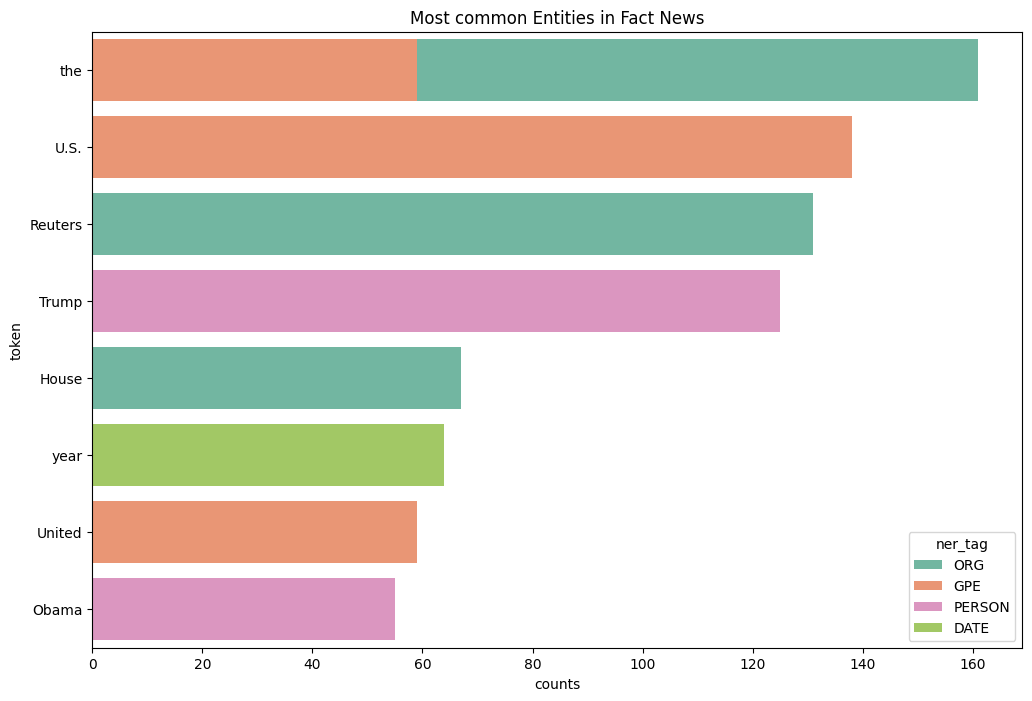

In [148]:
sns.barplot(
    x = 'counts',
    y = 'token',
    hue = 'ner_tag',
    palette = ner_palette,
    data = top_entities_fact[:10],
    orient = 'h',
    dodge = False
).set(title="Most common Entities in Fact News")

In [149]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"['two', 'small', 'problem', 'analogy', 'susan'...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"['buried', 'trump', 'bonkers', 'interview', 'n...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"['woman', 'make', '50', 'percent', 'country', ...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"['u', 'defense', 'secretary', 'jim', 'mattis',...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"['northern', 'ireland', 'political', 'party', ...",0.8590,positive


In [150]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s","",x['text']), axis = 1)

In [151]:
data['text_clean'] = data['text_clean'].str.lower()

In [152]:
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']),axis=1)

In [153]:
en_stopwords = stopwords.words('english')
print(en_stopwords)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

In [154]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [155]:
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis =1)

In [156]:
lemmatizer = WordNetLemmatizer()
data['text_clean'] = data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [157]:
tokens_clean = sum(data['text_clean'], [])

In [158]:
unigrams = (pd.Series(nltk.ngrams(tokens_clean, 1)).value_counts()).reset_index()[:10]
print(unigrams)

           index  count
0        (said,)    592
1       (trump,)    580
2           (u,)    279
3       (state,)    275
4   (president,)    259
5       (would,)    226
6         (one,)    164
7        (year,)    141
8     (clinton,)    141
9  (republican,)    137


/var/folders/l_/bp11g9j930b5ldgl6l464kk80000gn/T/ipykernel_9598/552396042.py:3: UserWarning: 
The palette list has fewer values (1) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


[Text(0.5, 1.0, 'Most common Unigrams After Preprocessing')]

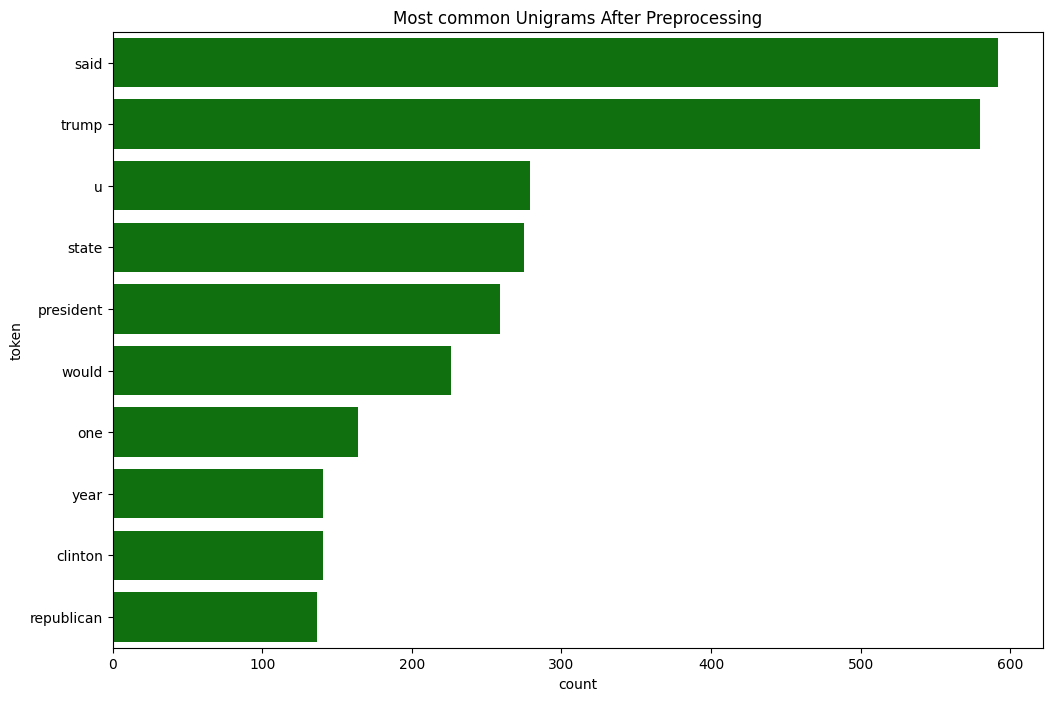

In [159]:
unigrams['token'] = unigrams['index'].apply(lambda x: x[0])

sns.barplot(
           x="count",
           y="token",
           data=unigrams,
           orient="h",
           palette=[default_plot_colour],
           hue="token", legend=False).set(title="Most common Unigrams After Preprocessing")

In [160]:
bigrams = (pd.Series(nltk.ngrams(tokens_clean, 2)).value_counts()).reset_index()[:10]
print(bigrams)

                     index  count
0          (donald, trump)    113
1          (united, state)     84
2           (white, house)     74
3      (president, donald)     47
4       (hillary, clinton)     39
5              (new, york)     33
6         (supreme, court)     30
7             (image, via)     29
8         (official, said)     26
9  (trump, administration)     26


In [161]:
vader_sentiment = SentimentIntensityAnalyzer()

In [162]:
data['vader_sentiment_score'] = data['text'].apply(lambda x: vader_sentiment.polarity_scores(x)['compound'])

In [163]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [164]:
bins = [-1,-0.1,0.1,1]
names = ['negative','neutral','positive']

In [165]:
data['vader_sentiment_label'] = pd.cut(data['vader_sentiment_score'], bins, labels=names)

In [166]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


<Axes: xlabel='vader_sentiment_label'>

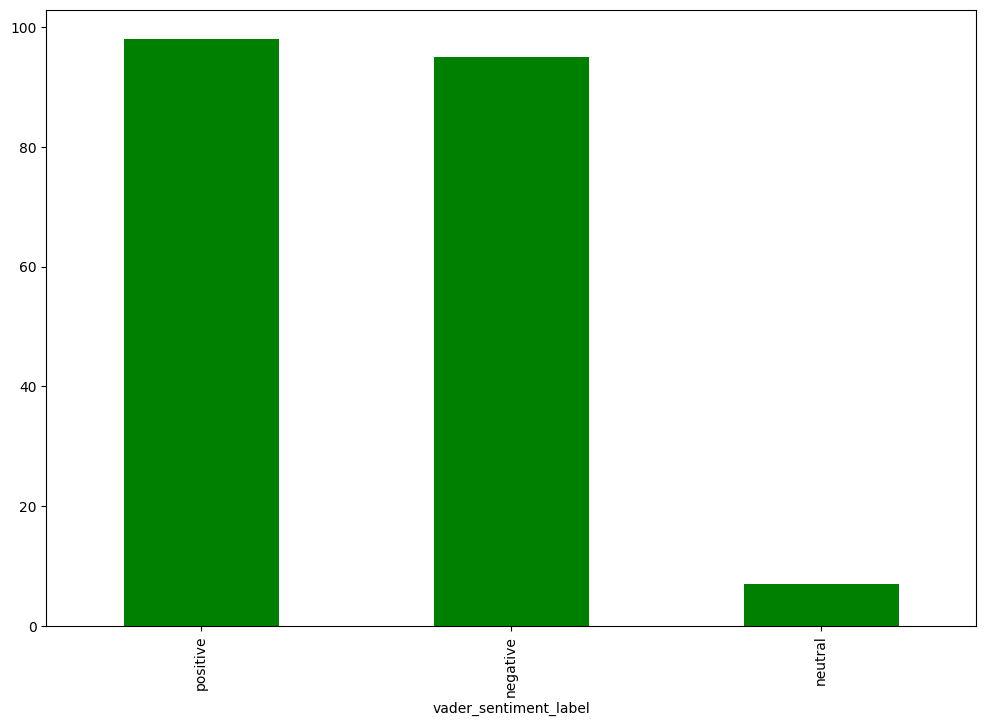

In [167]:
data['vader_sentiment_label'].value_counts().plot.bar(color=default_plot_colour)

/var/folders/l_/bp11g9j930b5ldgl6l464kk80000gn/T/ipykernel_9598/6889798.py:1: UserWarning: The palette list has more values (6) than needed (3), which may not be intended.
  sns.countplot(


[Text(0.5, 1.0, 'Sentiment by News Type')]

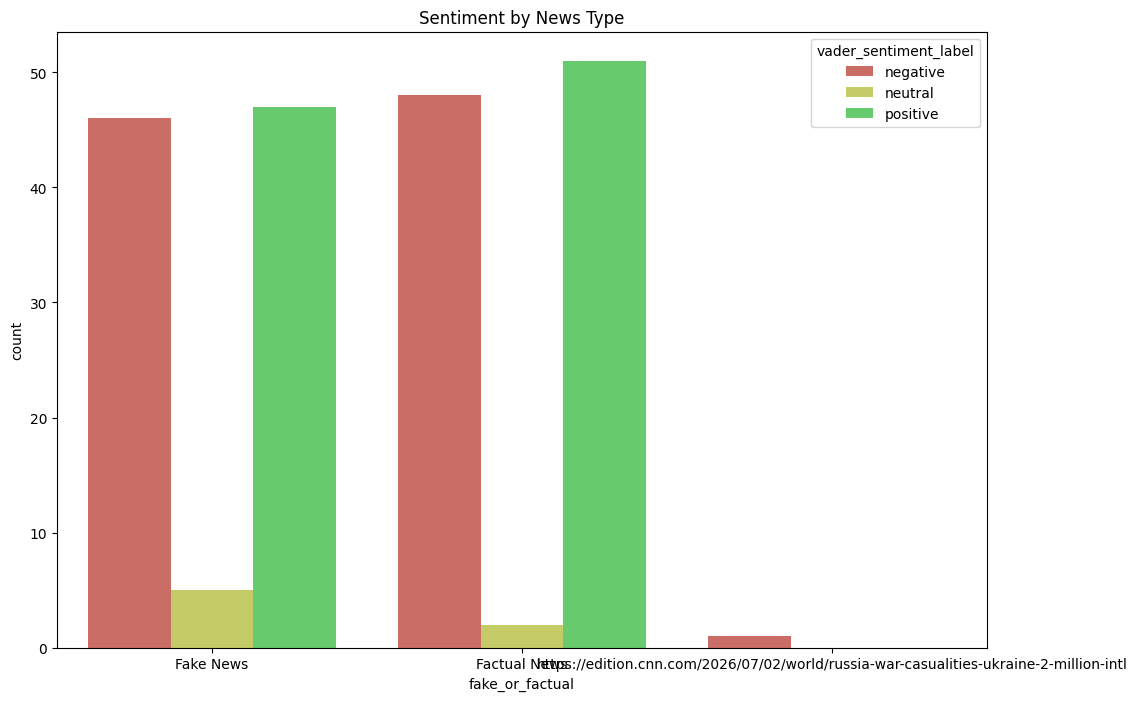

In [168]:
sns.countplot(
    x = 'fake_or_factual',
    hue = 'vader_sentiment_label',
    palette = sns.color_palette("hls"),
    data = data
).set(title = "Sentiment by News Type")

In [169]:
fake_news_text = data[data['fake_or_factual'] == "Fake News"]['text_clean'].reset_index(drop=True)

In [170]:
dictionary_fake = corpora.Dictionary(fake_news_text)

In [171]:
doc_term_fake = [dictionary_fake.doc2bow(text) for text in fake_news_text]

In [172]:
coherence_values = []
model_list = []
min_topics = 2
max_topics = 11

for num_topics_i in range(min_topics, max_topics+1):
    model = gensim.models.LdaModel(doc_term_fake, num_topics = num_topics_i, id2word = dictionary_fake)
    model_list.append(model)
    coherence_model = CoherenceModel(model=model, texts=fake_news_text, dictionary=dictionary_fake, coherence='c_v')
    coherence_values.append(coherence_model.get_coherence())

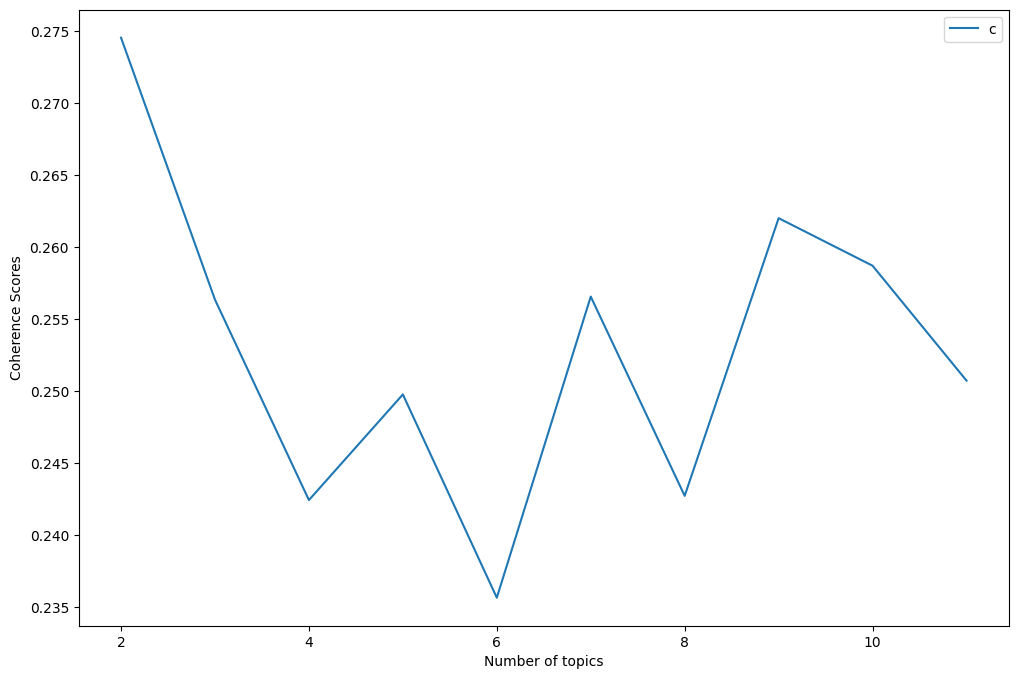

In [173]:
plt.plot(range(min_topics,max_topics+1), coherence_values)
plt.xlabel("Number of topics")
plt.ylabel("Coherence Scores")
plt.legend(("coherence_values"), loc="best")
plt.show()

In [174]:
num_topics_lda = 7
lda_model = gensim.models.LdaModel(corpus=doc_term_fake, id2word=dictionary_fake, num_topics=num_topics_lda)

In [175]:
lda_model.print_topics(num_topics_lda, num_words=10)

[(0,
  '0.013*"trump" + 0.005*"clinton" + 0.004*"president" + 0.004*"said" + 0.004*"donald" + 0.004*"u" + 0.003*"state" + 0.003*"would" + 0.003*"hillary" + 0.003*"republican"'),
 (1,
  '0.013*"trump" + 0.006*"one" + 0.005*"said" + 0.005*"clinton" + 0.005*"state" + 0.005*"u" + 0.005*"president" + 0.004*"would" + 0.004*"people" + 0.004*"woman"'),
 (2,
  '0.010*"trump" + 0.008*"president" + 0.005*"said" + 0.004*"state" + 0.004*"would" + 0.004*"time" + 0.003*"clinton" + 0.003*"woman" + 0.003*"year" + 0.003*"image"'),
 (3,
  '0.014*"trump" + 0.004*"president" + 0.004*"republican" + 0.004*"said" + 0.004*"time" + 0.003*"state" + 0.003*"donald" + 0.003*"school" + 0.003*"even" + 0.003*"clinton"'),
 (4,
  '0.011*"trump" + 0.004*"said" + 0.004*"clinton" + 0.004*"would" + 0.004*"state" + 0.003*"obama" + 0.003*"time" + 0.003*"people" + 0.003*"one" + 0.003*"donald"'),
 (5,
  '0.006*"trump" + 0.005*"said" + 0.004*"u" + 0.004*"one" + 0.004*"clinton" + 0.004*"state" + 0.004*"mccain" + 0.003*"syria" + 0

In [176]:
def tfidf_corpus(doc_term_matrix):
    tfidf = TfidfModel(corpus = doc_term_matrix, normalize = True)
    corpus_tfidf = tfidf[doc_term_matrix]
    return corpus_tfidf

In [177]:
def get_coherence_scores(corpus,dictionary, text, min_topics, max_topics):
    coherence_values = []
    model_list = []
    for num_topics_i in range(min_topics, max_topics+1):
        model = LsiModel(corpus, num_topics = num_topics_i, id2word = dictionary)
        model_list.append(model)
        coherence_model = CoherenceModel(model = model, texts=text, dictionary=dictionary, coherence = 'c_v')
        coherence_values.append(coherence_model.get_coherence())


    plt.plot(range(min_topics, max_topics+1), coherence_values)
    plt.xlabel("Number of Topics")
    plt.ylabel("Coherence score")
    plt.legend(("Coherence_values"), loc="best")
    plt.show()

In [178]:
corpus_tfidf_fake = tfidf_corpus(doc_term_fake)

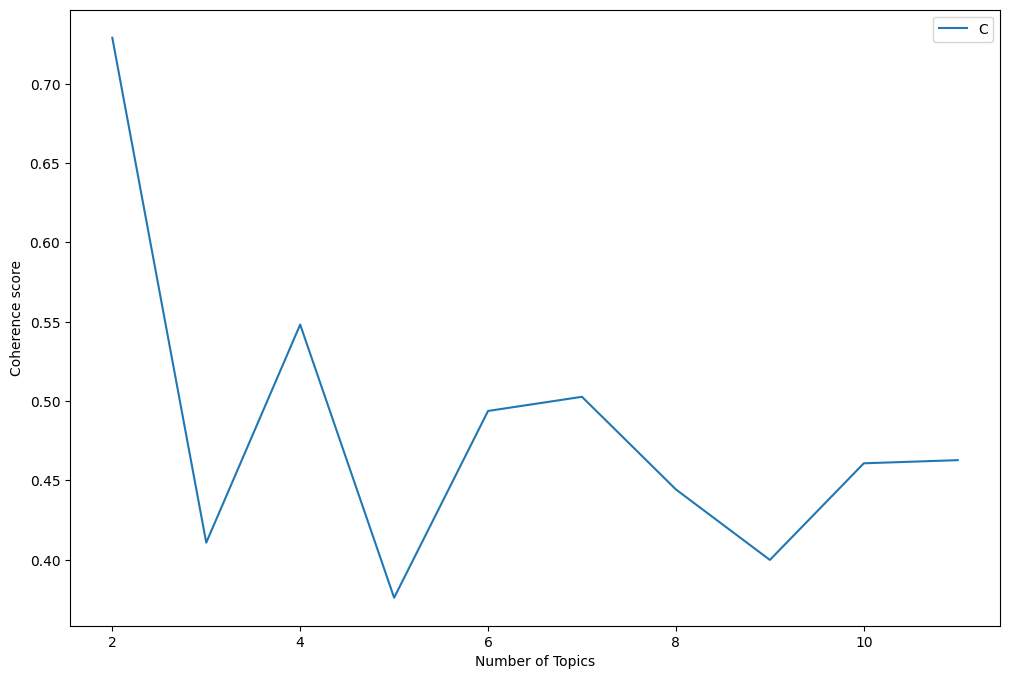

In [179]:
get_coherence_scores(corpus_tfidf_fake, dictionary_fake, fake_news_text, min_topics=2, max_topics=11)

In [180]:
lsa_model = LsiModel(corpus_tfidf_fake, id2word=dictionary_fake, num_topics = 7)

In [181]:
lsa_model.print_topics()

[(0,
  '0.190*"trump" + 0.136*"clinton" + 0.095*"hillary" + 0.094*"obama" + 0.089*"president" + 0.087*"woman" + 0.078*"republican" + 0.077*"party" + 0.077*"flynn" + 0.074*"candidate"'),
 (1,
  '-0.325*"boiler" + -0.284*"acr" + -0.244*"room" + -0.240*"pm" + -0.186*"broadcast" + -0.180*"radio" + -0.142*"tune" + -0.142*"animal" + -0.134*"jay" + -0.132*"episode"'),
 (2,
  '-0.623*"flynn" + -0.182*"immunity" + -0.122*"nana" + -0.116*"mr" + -0.110*"30" + -0.108*"march" + -0.102*"russian" + -0.100*"source" + 0.095*"school" + -0.092*"adviser"'),
 (3,
  '0.217*"clinton" + -0.186*"school" + -0.176*"student" + 0.141*"hillary" + -0.121*"county" + -0.121*"flynn" + 0.110*"sander" + 0.098*"debate" + 0.097*"woman" + 0.091*"nominee"'),
 (4,
  '0.200*"email" + -0.194*"trump" + 0.168*"dnc" + -0.142*"flynn" + 0.126*"clinton" + -0.112*"cruz" + 0.111*"department" + 0.110*"rich" + 0.102*"wikileaks" + 0.099*"sander"'),
 (5,
  '0.276*"student" + 0.160*"conference" + 0.160*"school" + 0.137*"trump" + -0.125*"mcc

In [182]:
data.head()

,title,text,date,fake_or_factual,text_clean,vader_sentiment_score,vader_sentiment_label
0,HOLLYWEIRD LIB SUSAN SARANDON Compares Muslim ...,There are two small problems with your analogy...,"Dec 30, 2015",Fake News,"[two, small, problem, analogy, susan, jesus, m...",-0.3660,negative
1,Elijah Cummings Called Trump Out To His Face ...,Buried in Trump s bonkers interview with New Y...,"April 6, 2017",Fake News,"[buried, trump, bonkers, interview, new, york,...",-0.8197,negative
2,Hillary Clinton Says Half Her Cabinet Will Be...,"Women make up over 50 percent of this country,...","April 26, 2016",Fake News,"[woman, make, 50, percent, country, grossly, u...",0.9779,positive
3,Russian bombing of U.S.-backed forces being di...,WASHINGTON (Reuters) - U.S. Defense Secretary ...,"September 18, 2017",Factual News,"[u, defense, secretary, jim, mattis, said, mon...",-0.3400,negative
4,Britain says window to restore Northern Irelan...,BELFAST (Reuters) - Northern Ireland s politic...,"September 4, 2017",Factual News,"[northern, ireland, political, party, rapidly,...",0.8590,positive


In [183]:
x = [','.join(map(str,i)) for i in data['text_clean']]
y = data['fake_or_factual']

In [184]:
countvec = CountVectorizer()

In [185]:
countvec_fit = countvec.fit_transform(x)

In [186]:
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [187]:
x_train, x_test, y_train, y_test = train_test_split(bag_of_words, y, test_size = 0.3)

In [188]:
lr = LogisticRegression(random_state=0).fit(x_train, y_train)

In [189]:
y_pred_lr = lr.predict(x_test)

In [190]:
accuracy_score(y_pred_lr, y_test)

0.85

In [191]:
print(classification_report(y_test,y_pred_lr))

              precision    recall  f1-score   support

Factual News       0.89      0.87      0.88        38
   Fake News       0.78      0.82      0.80        22

    accuracy                           0.85        60
   macro avg       0.84      0.84      0.84        60
weighted avg       0.85      0.85      0.85        60



In [192]:
svm = SGDClassifier().fit(x_train,y_train)

In [193]:
y_pred_svm = svm.predict(x_test)

In [194]:
accuracy_score(y_pred_svm, y_test)

0.8833333333333333

In [195]:
import requests
from bs4 import BeautifulSoup

In [196]:
def get_article_text(url):
    response = requests.get(url)
    soup = BeautifulSoup(response.text, 'html.parser')
    paragraphs = soup.find_all('p')
    article_text = ' '.join([p.get_text() for p in paragraphs])
    return article_text

In [197]:
url = input("Insert Article Link: ")

Insert Article Link:  https://edition.cnn.com/2026/07/02/world/russia-war-casualities-ukraine-2-million-intl


In [198]:
article_text = get_article_text(url)

In [199]:
article_clean = re.sub(r"^[^-]*-\s","",article_text)

In [200]:
article_clean = article_clean.lower()

In [201]:
article_clean = re.sub(r"([^\w\s])", "", article_clean)

In [202]:
article_clean = ' '.join([word for word in article_clean.split() if word not in (en_stopwords)])

In [203]:
article_clean = word_tokenize(article_clean)

In [204]:
article_clean = [lemmatizer.lemmatize(token) for token in article_clean]

In [205]:
article_vec = ','.join(map(str,article_clean))

In [206]:
article_bow = countvec.transform([article_vec])

In [207]:
print("Prediction (Logistic Regression):", article_pred_lr[0])
print("Prediction (SVM):", article_pred_svm[0])

Prediction (Logistic Regression): Factual News
Prediction (SVM): Fake News


In [208]:
faktyczna_etykieta = input("Provide the correct label for this Article (Fake News / Factual News): ")

Provide the correct label for this Article (Fake News / Factual News):  Factual News


In [209]:
new_row = pd.DataFrame({'text':[article_text], 'fake_or_factual':[faktyczna_etykieta]})
data = pd.concat([data, new_row], ignore_index=True)

In [210]:
data.to_csv("fake_news_data.csv", index=False)

In [211]:
data['text_clean'] = data.apply(lambda x: re.sub(r"^[^-]*-\s","",x['text']), axis = 1)

In [212]:
data['text_clean'] = data['text_clean'].str.lower()

In [213]:
data['text_clean'] = data.apply(lambda x: re.sub(r"([^\w\s])", "", x['text_clean']),axis=1)

In [214]:
data['text_clean'] = data['text_clean'].apply(lambda x: ' '.join([word for word in x.split() if word not in (en_stopwords)]))

In [215]:
data['text_clean'] = data.apply(lambda x: word_tokenize(x['text_clean']), axis =1)

In [216]:
data['text_clean'] = data['text_clean'].apply(lambda tokens: [lemmatizer.lemmatize(token) for token in tokens])

In [217]:
x = [','.join(map(str,i)) for i in data['text_clean']]
y = data['fake_or_factual']

In [218]:
countvec = CountVectorizer()
countvec_fit = countvec.fit_transform(x)
bag_of_words = pd.DataFrame(countvec_fit.toarray(), columns=countvec.get_feature_names_out())

In [219]:
x_train, x_test, y_train, y_test = train_test_split(bag_of_words, y, test_size = 0.3)

In [223]:
lr = LogisticRegression(random_state=0).fit(x_train, y_train)
svm = SGDClassifier().fit(x_train,y_train)

In [224]:
y_pred_lr = lr.predict(x_test)
y_pred_svm = svm.predict(x_test)

In [225]:
print(accuracy_score(y_pred_lr, y_test))
print(accuracy_score(y_pred_svm, y_test))

0.8524590163934426
0.8360655737704918
